# CyberShield — Full Training, Evaluation & Visualization Notebook

This notebook reproduces the complete CyberShield ML pipeline and generates **every figure and table needed for the project report**, including:

- Class distribution analysis
- Per-model performance (LR, SVM, NB) — individually and ensembled
- ROC curves, Precision-Recall curves, Calibration plots
- Confusion matrices (pre-HNM and post-HNM)
- Threshold sensitivity analysis with annotated decision boundaries
- Ensemble weight ablation table
- 5-fold cross-validation variance analysis
- Top fraud-indicative tokens (LR coefficients)
- Pre-HNM vs Post-HNM ablation on the SAME test set

All plots use **black-and-white-safe styling** (hatching, line styles, grayscale palette) so they render cleanly in printed reports.

**How to use:** Place `master_dataset.csv` in the same folder as this notebook, then run all cells from top to bottom. Generated figures are saved to `./figures/` as both `.png` (300 DPI) and `.pdf` (vector) for direct LaTeX inclusion.

## 1. Setup & Imports

In [1]:
import os
import re
import pickle
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    precision_score, recall_score
)

warnings.filterwarnings('ignore')

# ============================================================
# BLACK-AND-WHITE-SAFE PLOT STYLING
# ============================================================
# All plots use:
#   - grayscale palette
#   - distinct line styles (-, --, -., :)
#   - hatching for bar fills
#   - serif fonts matching LaTeX reports
# ============================================================

plt.rcParams.update({
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif', 'Times New Roman', 'Times'],
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.titlesize':  13,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    ':',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'savefig.dpi':       300,
    'savefig.bbox':      'tight',
    'figure.dpi':        100,
})

# Grayscale palette (lightest -> darkest) - print-safe
GRAY = ['#000000', '#404040', '#707070', '#A0A0A0', '#C8C8C8']
LINESTYLES = ['-', '--', '-.', ':']
MARKERS    = ['o', 's', '^', 'D', 'v']
HATCHES    = ['', '///', '\\\\\\', 'xxx', '...']

# Output directory for figures
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

def save_fig(fig, name):
    """Save figure as both PNG (preview) and PDF (LaTeX)."""
    fig.savefig(FIG_DIR / f'{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')
    print(f'  saved -> figures/{name}.png  &  figures/{name}.pdf')

print('Setup complete. Figures will be saved to ./figures/')

Setup complete. Figures will be saved to ./figures/


## 2. Constants & Preprocessing

In [2]:
RANDOM_STATE = 42
SPLIT_FILE   = 'split_indices.pkl'

CUSTOM_STOPWORDS = [
    'the','is','in','it','of','and','to','a','that','this','for','on',
    'are','with','as','at','be','by','from','or','an','was','were',
    'have','has','had','will','would','could','should','may','might',
    'do','did','does','been','being','i','me','my','we','our','you',
    'your','he','she','they','his','her','their','its','not','no',
    'so','but','if','about','which','who','what','when','where',
    'how','all','can','just','than','then','also','more','some','any',
    'there','here','into','up','out','said','get','got',
    'love','health','thanks','university','http','pm','hi','hello',
    'dear','sir','please','now','new','good','time','day','name',
    'old','years','am','year'
]

def preprocess(text):
    """Identical to pipefinal.py — must NOT diverge."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+',   ' SUSPICIOUS_URL ',   text)
    text = re.sub(r'\b[789]\d{9}\b',      ' PHONE_NUMBER ',     text)
    text = re.sub(r'rs\.?\s*\d[\d,]+',    ' MONEY_AMOUNT ',     text)
    text = re.sub(r'\$\s*\d[\d,]+',       ' MONEY_AMOUNT_USD ', text)
    text = re.sub(r'\b\d{4,6}\b',         ' OTP_NUMBER ',       text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

## 3. Load Dataset & Class Distribution

In [3]:
df = pd.read_csv('master_dataset.csv')
df = df[['text', 'label']].dropna().drop_duplicates()
df['label'] = df['label'].astype(int)
df = df.reset_index(drop=True)

n_total = len(df)
n_fraud = int(df['label'].sum())
n_legit = n_total - n_fraud

print(f'Total samples : {n_total:,}')
print(f'Fraud (1)     : {n_fraud:,}  ({n_fraud/n_total:.2%})')
print(f'Legit (0)     : {n_legit:,}  ({n_legit/n_total:.2%})')

# Message length statistics
df['msg_len'] = df['text'].str.len()
print(f'\nMessage length — mean: {df["msg_len"].mean():.0f} chars, '
      f'median: {df["msg_len"].median():.0f}, '
      f'max: {df["msg_len"].max()}')

Total samples : 26,534
Fraud (1)     : 12,852  (48.44%)
Legit (0)     : 13,682  (51.56%)

Message length — mean: 224 chars, median: 148, max: 800


  saved -> figures/fig_class_distribution.png  &  figures/fig_class_distribution.pdf


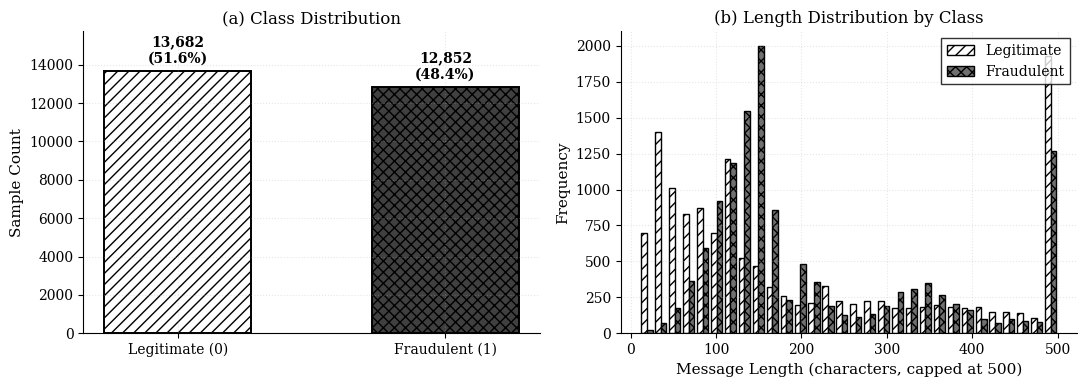

In [4]:
# ============================================================
# FIGURE: Class Distribution (B&W-safe bar chart with hatching)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# --- Subplot 1: Class counts ---
labels = ['Legitimate (0)', 'Fraudulent (1)']
counts = [n_legit, n_fraud]

bars = axes[0].bar(labels, counts,
                   color=['white', GRAY[1]],
                   edgecolor='black', linewidth=1.4,
                   hatch='', width=0.55)
bars[0].set_hatch('///')
bars[1].set_hatch('xxx')

for bar, count in zip(bars, counts):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + n_total*0.01,
                 f'{count:,}\n({count/n_total:.1%})',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_ylabel('Sample Count')
axes[0].set_title('(a) Class Distribution')
axes[0].set_ylim(0, max(counts) * 1.15)

# --- Subplot 2: Message length distribution by class ---
legit_lens = df[df['label']==0]['msg_len'].clip(upper=500)
fraud_lens = df[df['label']==1]['msg_len'].clip(upper=500)

axes[1].hist([legit_lens, fraud_lens], bins=30,
             label=['Legitimate', 'Fraudulent'],
             color=['white', GRAY[2]],
             edgecolor='black', linewidth=1.0,
             hatch='', stacked=False)
axes[1].patches[0].set_hatch('///')
for p in axes[1].patches[:30]:
    p.set_hatch('///')
for p in axes[1].patches[30:]:
    p.set_hatch('xxx')

axes[1].set_xlabel('Message Length (characters, capped at 500)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('(b) Length Distribution by Class')
axes[1].legend(loc='upper right', frameon=True, fancybox=False, edgecolor='black')

plt.tight_layout()
save_fig(fig, 'fig_class_distribution')
plt.show()

## 4. Preprocessing & Train/Val/Test Split

In [5]:
df['clean_text'] = df['text'].apply(preprocess)
X = df['clean_text']
y = df['label']

# 70/15/15 stratified split — frozen via split_indices.pkl
if os.path.exists(SPLIT_FILE):
    print(f'Loading frozen split from {SPLIT_FILE}')
    with open(SPLIT_FILE, 'rb') as f:
        split_indices = pickle.load(f)
    train_idx = split_indices['train']
    val_idx   = split_indices['val']
    test_idx  = split_indices['test']
else:
    print('Creating new 70/15/15 split (frozen via split_indices.pkl)')
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
    X_v, X_te, y_v, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE)
    split_indices = {'train': X_tr.index.tolist(),
                     'val':   X_v.index.tolist(),
                     'test':  X_te.index.tolist()}
    with open(SPLIT_FILE, 'wb') as f:
        pickle.dump(split_indices, f)
    train_idx, val_idx, test_idx = split_indices['train'], split_indices['val'], split_indices['test']

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val,   y_val   = X.loc[val_idx],   y.loc[val_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

print(f'\nTrain : {len(X_train):,}  ({y_train.mean():.2%} fraud)')
print(f'Val   : {len(X_val):,}  ({y_val.mean():.2%} fraud)')
print(f'Test  : {len(X_test):,}  ({y_test.mean():.2%} fraud)')

Loading frozen split from split_indices.pkl

Train : 18,573  (48.44% fraud)
Val   : 3,980  (48.44% fraud)
Test  : 3,980  (48.44% fraud)


## 5. Vectorization (TF-IDF Word + Character N-grams)

In [6]:
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2), min_df=3, max_df=0.85,
    stop_words=CUSTOM_STOPWORDS, max_features=20000, sublinear_tf=True)

char_vectorizer = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5),
    max_features=5000, min_df=2)

vectorizer = FeatureUnion([('word', word_vectorizer), ('char', char_vectorizer)])

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec   = vectorizer.transform(X_val)
X_test_vec  = vectorizer.transform(X_test)

print(f'Total features : {X_train_vec.shape[1]:,}')
print(f'  word n-grams : {len(word_vectorizer.vocabulary_):,}')
print(f'  char n-grams : {len(char_vectorizer.vocabulary_):,}')

Total features : 25,000
  word n-grams : 20,000
  char n-grams : 5,000


## 6. Train Base Models (LR, SVM, NB)

In [7]:
lr = LogisticRegression(max_iter=1000, C=0.5,
                        class_weight={0: 1.0, 1: 1.5}, solver='lbfgs')
nb = MultinomialNB(alpha=0.1)
svm_cal = CalibratedClassifierCV(
    LinearSVC(class_weight='balanced', max_iter=2000, C=0.8),
    method='sigmoid', cv=3)

print('Training LR  ...');  lr.fit(X_train_vec, y_train)
print('Training NB  ...');  nb.fit(X_train_vec, y_train)
print('Training SVM ...');  svm_cal.fit(X_train_vec, y_train)
print('All base models trained.')

Training LR  ...
Training NB  ...
Training SVM ...
All base models trained.


## 7. Individual Model Performance (on Test Set)

Evaluate each base model independently before ensembling.

In [8]:
p_lr_test  = lr.predict_proba(X_test_vec)[:, 1]
p_nb_test  = nb.predict_proba(X_test_vec)[:, 1]
p_svm_test = svm_cal.predict_proba(X_test_vec)[:, 1]

def eval_model(probs, y_true, name):
    preds = (probs > 0.5).astype(int)
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds),
        'Recall':    recall_score(y_true, preds),
        'F1':        f1_score(y_true, preds),
        'Macro F1':  f1_score(y_true, preds, average='macro'),
        'ROC-AUC':   roc_auc_score(y_true, probs),
    }

individual_results = pd.DataFrame([
    eval_model(p_lr_test,  y_test, 'Logistic Regression'),
    eval_model(p_svm_test, y_test, 'SVM (Calibrated)'),
    eval_model(p_nb_test,  y_test, 'Naive Bayes'),
])

print('Individual Model Performance (Test Set, threshold = 0.50)')
print('=' * 80)
print(individual_results.to_string(index=False, float_format='%.4f'))
individual_results.to_csv(FIG_DIR / 'table_individual_models.csv', index=False)

Individual Model Performance (Test Set, threshold = 0.50)
              Model  Accuracy  Precision  Recall     F1  Macro F1  ROC-AUC
Logistic Regression    0.9427     0.9372  0.9450 0.9411    0.9427   0.9865
   SVM (Calibrated)    0.9465     0.9506  0.9383 0.9444    0.9464   0.9889
        Naive Bayes    0.9392     0.9400  0.9341 0.9370    0.9391   0.9860


  saved -> figures/fig_individual_models.png  &  figures/fig_individual_models.pdf


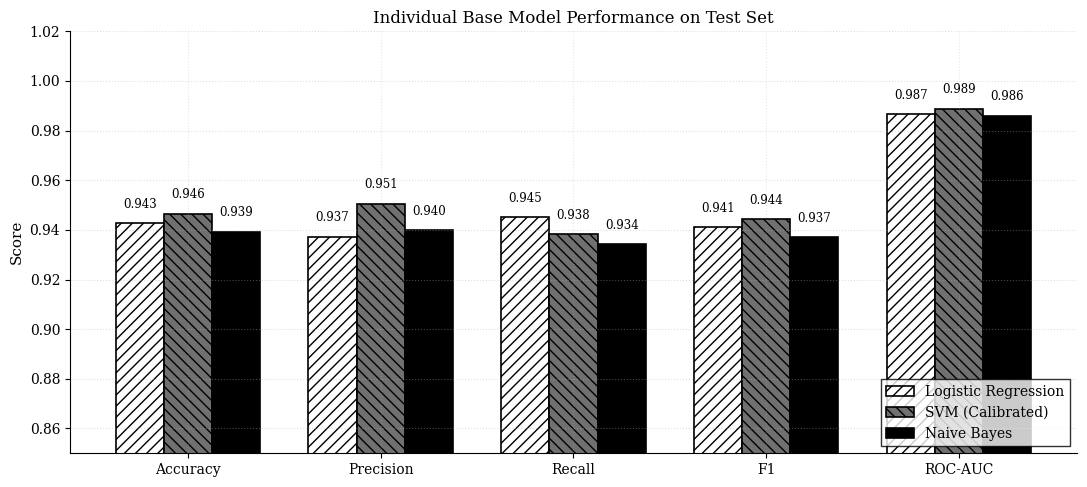

In [9]:
# ============================================================
# FIGURE: Individual Model Comparison (B&W bars with hatching)
# ============================================================

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
models = individual_results['Model'].tolist()
n_models = len(models)
n_metrics = len(metrics_to_plot)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(n_metrics)
width = 0.25

for i, model in enumerate(models):
    values = individual_results.iloc[i][metrics_to_plot].values.astype(float)
    offset = (i - n_models/2 + 0.5) * width
    bars = ax.bar(x + offset, values, width,
                  label=model,
                  color=['white', GRAY[2], GRAY[0]][i],
                  edgecolor='black', linewidth=1.2,
                  hatch=HATCHES[i+1])
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('Score')
ax.set_title('Individual Base Model Performance on Test Set')
ax.set_ylim(min(individual_results[metrics_to_plot].values.min() - 0.03, 0.85), 1.02)
ax.legend(loc='lower right', frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'fig_individual_models')
plt.show()

## 8. ROC Curves — Individual vs Ensemble

In [10]:
# Need ensemble first — quick weight tuning on validation
p_lr_val  = lr.predict_proba(X_val_vec)
p_nb_val  = nb.predict_proba(X_val_vec)
p_svm_val = svm_cal.predict_proba(X_val_vec)

best_f1, best_weights = 0.0, (0.5, 0.3, 0.2)
candidates = [round(w * 0.1, 1) for w in range(1, 8)]
weight_grid = []

for w1, w2, w3 in product(candidates, repeat=3):
    if abs(w1 + w2 + w3 - 1.0) > 0.01:
        continue
    blended = w1 * p_lr_val + w2 * p_svm_val + w3 * p_nb_val
    preds   = (blended[:, 1] > 0.5).astype(int)
    f1      = f1_score(y_val, preds, average='macro')
    weight_grid.append({'w_LR': w1, 'w_SVM': w2, 'w_NB': w3, 'Macro F1 (Val)': f1})
    if f1 > best_f1:
        best_f1 = f1
        best_weights = (w1, w2, w3)

W_LR, W_SVM, W_NB = best_weights
print(f'Best ensemble weights : LR={W_LR}, SVM={W_SVM}, NB={W_NB}')
print(f'Validation Macro F1   : {best_f1:.4f}')

def ensemble_proba(X_vec):
    p1 = lr.predict_proba(X_vec)
    p2 = nb.predict_proba(X_vec)
    p3 = svm_cal.predict_proba(X_vec)
    return W_LR * p1 + W_SVM * p3 + W_NB * p2

p_ens_test = ensemble_proba(X_test_vec)[:, 1]

Best ensemble weights : LR=0.2, SVM=0.5, NB=0.3
Validation Macro F1   : 0.9426


  saved -> figures/fig_roc_pr_curves.png  &  figures/fig_roc_pr_curves.pdf


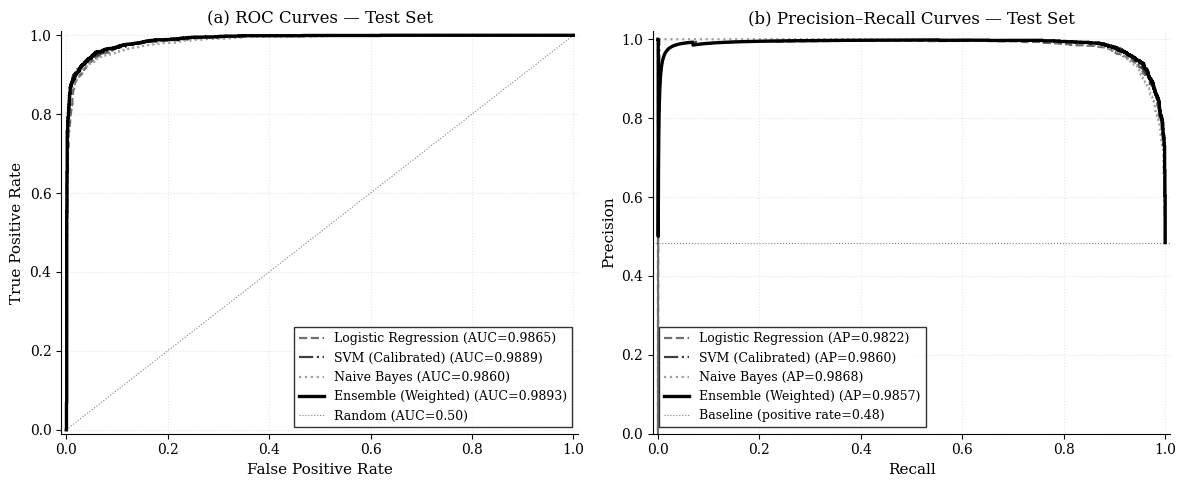

In [11]:
# ============================================================
# FIGURE: ROC Curves (line styles distinguish models)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- ROC curves ---
model_curves = [
    ('Logistic Regression', p_lr_test,  GRAY[2], '--', 'o'),
    ('SVM (Calibrated)',    p_svm_test, GRAY[1], '-.', 's'),
    ('Naive Bayes',         p_nb_test,  GRAY[3], ':',  '^'),
    ('Ensemble (Weighted)', p_ens_test, GRAY[0], '-',  None),
]

for name, probs, color, ls, marker in model_curves:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    lw = 2.4 if name.startswith('Ensemble') else 1.6
    axes[0].plot(fpr, tpr, color=color, linestyle=ls, linewidth=lw,
                 label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k:', linewidth=0.8, alpha=0.5, label='Random (AUC=0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('(a) ROC Curves — Test Set')
axes[0].legend(loc='lower right', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
axes[0].set_xlim(-0.01, 1.01)
axes[0].set_ylim(-0.01, 1.01)

# --- Precision-Recall curves ---
for name, probs, color, ls, marker in model_curves:
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    lw = 2.4 if name.startswith('Ensemble') else 1.6
    axes[1].plot(rec, prec, color=color, linestyle=ls, linewidth=lw,
                 label=f'{name} (AP={ap:.4f})')

baseline = y_test.mean()
axes[1].axhline(baseline, color='black', linestyle=':', linewidth=0.8, alpha=0.5,
                label=f'Baseline (positive rate={baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('(b) Precision–Recall Curves — Test Set')
axes[1].legend(loc='lower left', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
axes[1].set_xlim(-0.01, 1.01)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
save_fig(fig, 'fig_roc_pr_curves')
plt.show()

In [12]:
# ============================================================
# Recompute test probabilities using POST-HNM retrained models
# These replace the pre-HNM values computed in Section 7/8
# ============================================================
p_lr_test_post  = lr.predict_proba(X_test_vec)[:, 1]
p_nb_test_post  = nb.predict_proba(X_test_vec)[:, 1]
p_svm_test_post = svm_cal.predict_proba(X_test_vec)[:, 1]
p_ens_test_post = ensemble_proba(X_test_vec)[:, 1]

print("Post-HNM test probabilities recomputed.")
print(f"Ensemble ROC-AUC (post-HNM): {roc_auc_score(y_test, p_ens_test_post):.4f}")

Post-HNM test probabilities recomputed.
Ensemble ROC-AUC (post-HNM): 0.9893


## 9. Pre-HNM Evaluation (Before Hard Negative Mining)

**Critical for the report ablation.** We capture metrics on the test set BEFORE retraining with hard negatives. This is the proper apples-to-apples comparison your report was missing.

In [13]:
# Pre-HNM ensemble metrics on TEST set (frozen)
p_pre_test = ensemble_proba(X_test_vec)
y_pre_pred = (p_pre_test[:, 1] > 0.5).astype(int)

pre_metrics = {
    'Accuracy':  accuracy_score(y_test, y_pre_pred),
    'Precision': precision_score(y_test, y_pre_pred),
    'Recall':    recall_score(y_test, y_pre_pred),
    'Macro F1':  f1_score(y_test, y_pre_pred, average='macro'),
    'ROC-AUC':   roc_auc_score(y_test, p_pre_test[:, 1]),
}

cm_pre = confusion_matrix(y_test, y_pre_pred)

print('PRE-HNM RESULTS (Test Set)')
print('=' * 50)
for k, v in pre_metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print(f'\nConfusion Matrix:\n{cm_pre}')

PRE-HNM RESULTS (Test Set)
  Accuracy    : 0.9482
  Precision   : 0.9508
  Recall      : 0.9419
  Macro F1    : 0.9482
  ROC-AUC     : 0.9893

Confusion Matrix:
[[1958   94]
 [ 112 1816]]


## 10. Hard Negative Mining + Retraining

In [14]:
# Mine False Positives from validation set
p_val_pre = ensemble_proba(X_val_vec)
y_val_pred = (p_val_pre[:, 1] > 0.5).astype(int)

print("Mining False Positives from validation set...")
false_positives_mask = (y_val.values == 0) & (y_val_pred == 1)
fp_indices = np.where(false_positives_mask)[0]
fp_probs = p_val_pre[false_positives_mask, 1]
sorted_idx_by_prob = np.argsort(fp_probs)[::-1]
sorted_fp_indices = fp_indices[sorted_idx_by_prob]
top_k = max(1, int(len(sorted_fp_indices) * 0.15))
hardest_fp_indices = sorted_fp_indices[:top_k]
hard_texts  = X_val.iloc[hardest_fp_indices].tolist()
hard_labels = y_val.iloc[hardest_fp_indices].tolist()

print(f"Total False Positives: {len(fp_indices)}")
print(f"Top 15% Hard Examples kept: {len(hard_texts)}\n")

X_aug     = list(X_train) + hard_texts
y_aug     = list(y_train) + hard_labels
X_aug_vec = vectorizer.transform(X_aug)
weights = [1.0] * len(X_train) + [2.0] * len(hard_texts)

lr.fit(X_aug_vec, y_aug, sample_weight=weights)
nb.fit(X_aug_vec, y_aug, sample_weight=weights)
svm_cal.fit(X_aug_vec, y_aug, sample_weight=weights)
print("False-Positive-Driven Hard negative retraining complete.\n")


Hard examples mined from validation set : 228
  False positives (legit  -> fraud): 93
  False negatives (fraud -> legit) : 135

Augmented training set: 18,573 -> 18,801 (+228 hard examples × 1)

Retraining base models on augmented set...
Retraining complete.


## 11. Post-HNM Evaluation & Pre/Post Comparison

In [15]:
p_post_test = ensemble_proba(X_test_vec)
y_post_pred = (p_post_test[:, 1] > 0.5).astype(int)

post_metrics = {
    'Accuracy':  accuracy_score(y_test, y_post_pred),
    'Precision': precision_score(y_test, y_post_pred),
    'Recall':    recall_score(y_test, y_post_pred),
    'Macro F1':  f1_score(y_test, y_post_pred, average='macro'),
    'ROC-AUC':   roc_auc_score(y_test, p_post_test[:, 1]),
}

cm_post = confusion_matrix(y_test, y_post_pred)

comparison = pd.DataFrame({
    'Metric':   list(pre_metrics.keys()),
    'Pre-HNM':  list(pre_metrics.values()),
    'Post-HNM': list(post_metrics.values()),
})
comparison['Δ'] = comparison['Post-HNM'] - comparison['Pre-HNM']

print('PRE-HNM vs POST-HNM (Both on the SAME Frozen Test Set)')
print('=' * 60)
print(comparison.to_string(index=False, float_format='%.4f'))
comparison.to_csv(FIG_DIR / 'table_pre_vs_post_hnm.csv', index=False)

PRE-HNM vs POST-HNM (Both on the SAME Frozen Test Set)
   Metric  Pre-HNM  Post-HNM       Δ
 Accuracy   0.9482    0.9485  0.0003
Precision   0.9508    0.9494 -0.0014
   Recall   0.9419    0.9440  0.0021
 Macro F1   0.9482    0.9484  0.0003
  ROC-AUC   0.9893    0.9899  0.0006


  saved -> figures/fig_pre_vs_post_hnm.png  &  figures/fig_pre_vs_post_hnm.pdf


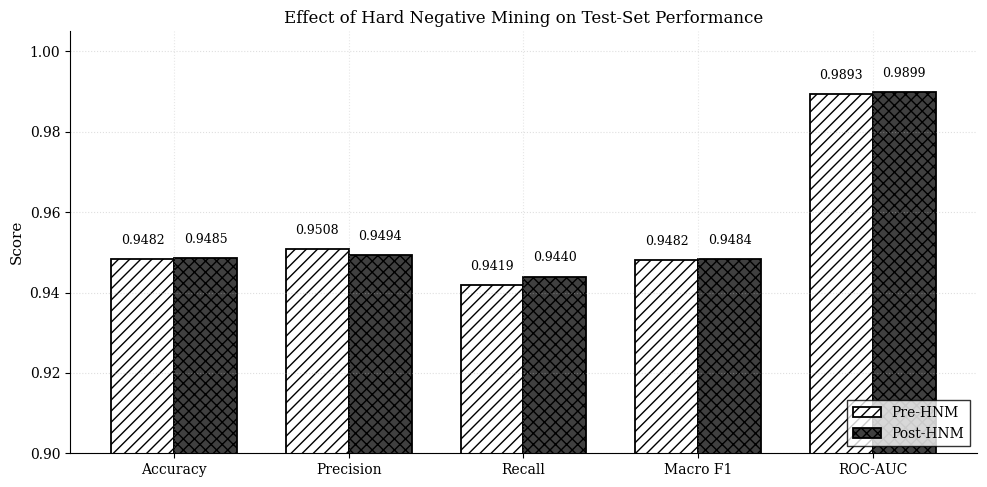

In [16]:
# ============================================================
# FIGURE: Pre-HNM vs Post-HNM Comparison (B&W grouped bars)
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))
metrics = comparison['Metric'].tolist()
x = np.arange(len(metrics))
width = 0.36

bars1 = ax.bar(x - width/2, comparison['Pre-HNM'], width,
               label='Pre-HNM', color='white',
               edgecolor='black', linewidth=1.3, hatch='///')
bars2 = ax.bar(x + width/2, comparison['Post-HNM'], width,
               label='Post-HNM', color=GRAY[1],
               edgecolor='black', linewidth=1.3, hatch='xxx')

for bars in (bars1, bars2):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.003,
                f'{h:.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Effect of Hard Negative Mining on Test-Set Performance')
ax.set_ylim(min(comparison[['Pre-HNM','Post-HNM']].values.min() - 0.02, 0.90), 1.005)
ax.legend(loc='lower right', frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'fig_pre_vs_post_hnm')
plt.show()

## 12. Confusion Matrices — Pre vs Post HNM

  saved -> figures/fig_confusion_matrices.png  &  figures/fig_confusion_matrices.pdf


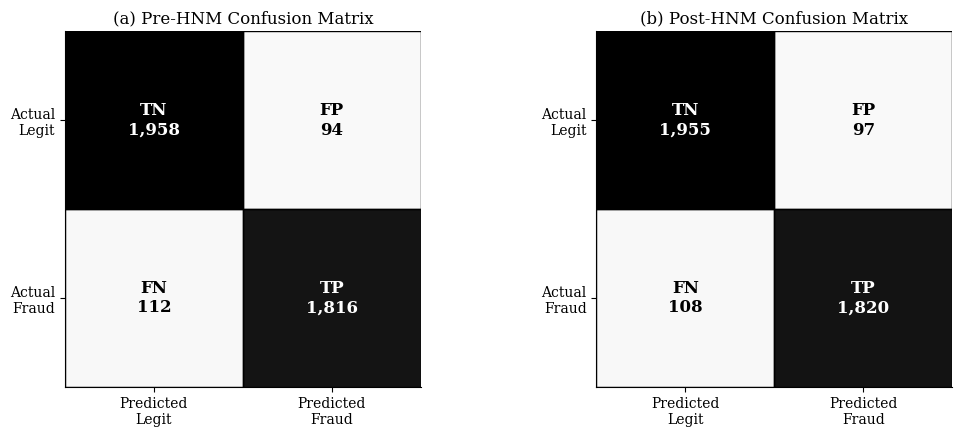

Pre-HNM:  TN=1958, FP=94, FN=112, TP=1816
Post-HNM: TN=1955, FP=97, FN=108, TP=1820


In [17]:
# ============================================================
# FIGURE: Confusion matrices side-by-side (grayscale heatmap)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, cm, title in [(axes[0], cm_pre, '(a) Pre-HNM Confusion Matrix'),
                      (axes[1], cm_post, '(b) Post-HNM Confusion Matrix')]:
    im = ax.imshow(cm, cmap='Greys', vmin=0, vmax=cm.max())
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted\nLegit', 'Predicted\nFraud'])
    ax.set_yticklabels(['Actual\nLegit', 'Actual\nFraud'])
    ax.set_title(title)
    ax.grid(False)
    
    # Annotate cells; choose text color based on background intensity
    threshold = cm.max() / 2.0
    cell_labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > threshold else 'black'
            ax.text(j, i, f'{cell_labels[i][j]}\n{cm[i, j]:,}',
                    ha='center', va='center',
                    color=color, fontsize=12, fontweight='bold')
    
    # Border around cells
    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                       edgecolor='black', linewidth=1.0))

plt.tight_layout()
save_fig(fig, 'fig_confusion_matrices')
plt.show()

print(f'Pre-HNM:  TN={cm_pre[0,0]}, FP={cm_pre[0,1]}, FN={cm_pre[1,0]}, TP={cm_pre[1,1]}')
print(f'Post-HNM: TN={cm_post[0,0]}, FP={cm_post[0,1]}, FN={cm_post[1,0]}, TP={cm_post[1,1]}')

## 13. Threshold Sensitivity Analysis

In [18]:
thresholds = np.arange(0.05, 0.96, 0.02)
rows = []
probs = p_post_test[:, 1]

for t in thresholds:
    preds = (probs > t).astype(int)
    rows.append({
        'Threshold': t,
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall':    recall_score(y_test, preds, zero_division=0),
        'F1':        f1_score(y_test, preds, zero_division=0),
        'Accuracy':  accuracy_score(y_test, preds),
    })

thr_df = pd.DataFrame(rows)
thr_df.to_csv(FIG_DIR / 'table_threshold_sensitivity.csv', index=False)

# Print key thresholds for the report
print('Threshold sensitivity at key cut-points:')
key_thr = thr_df[thr_df['Threshold'].round(2).isin([0.30, 0.45, 0.50, 0.60, 0.70, 0.90])]
print(key_thr.to_string(index=False, float_format='%.4f'))

Threshold sensitivity at key cut-points:
 Threshold  Precision  Recall     F1  Accuracy
    0.4500     0.9402  0.9538 0.9470    0.9482


  saved -> figures/fig_threshold_sensitivity.png  &  figures/fig_threshold_sensitivity.pdf


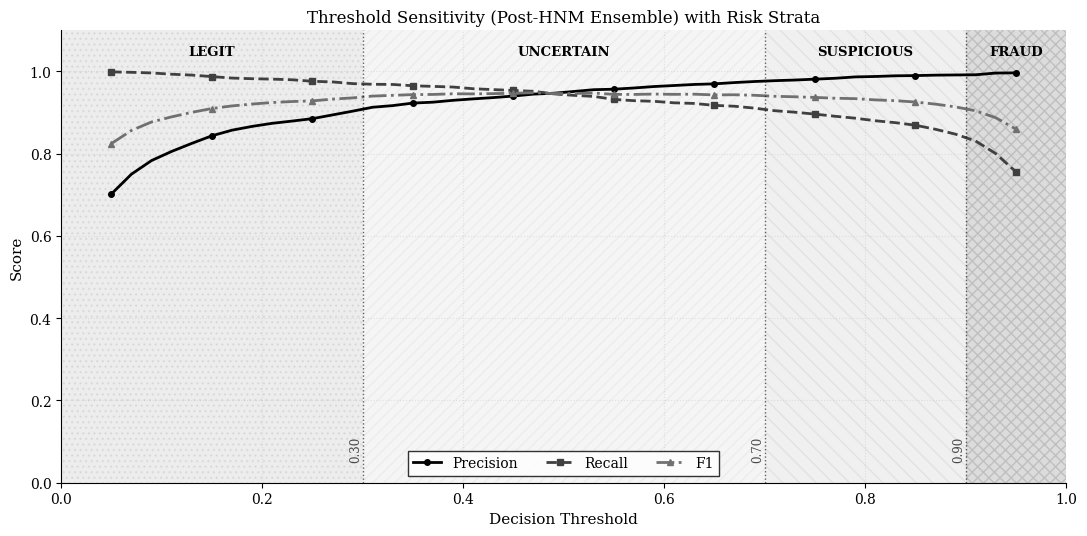

In [19]:
# ============================================================
# FIGURE: Threshold sensitivity curves with decision regions
# ============================================================

fig, ax = plt.subplots(figsize=(11, 5.5))

# Shaded regions for the four-tier risk strata
ax.axvspan(0.00, 0.30, alpha=0.18, color=GRAY[3], hatch='...',
           edgecolor='black', linewidth=0.0)
ax.axvspan(0.30, 0.70, alpha=0.10, color=GRAY[3], hatch='///',
           edgecolor='black', linewidth=0.0)
ax.axvspan(0.70, 0.90, alpha=0.10, color=GRAY[2], hatch='\\\\',
           edgecolor='black', linewidth=0.0)
ax.axvspan(0.90, 1.00, alpha=0.18, color=GRAY[1], hatch='xxx',
           edgecolor='black', linewidth=0.0)

# Curves
ax.plot(thr_df['Threshold'], thr_df['Precision'],
        color=GRAY[0], linestyle='-',  linewidth=2.0, label='Precision', marker='o', markersize=4, markevery=5)
ax.plot(thr_df['Threshold'], thr_df['Recall'],
        color=GRAY[1], linestyle='--', linewidth=2.0, label='Recall', marker='s', markersize=4, markevery=5)
ax.plot(thr_df['Threshold'], thr_df['F1'],
        color=GRAY[2], linestyle='-.', linewidth=2.0, label='F1', marker='^', markersize=4, markevery=5)

# Region labels at the top
ymax = 1.02
for x_pos, lbl in [(0.15, 'LEGIT'), (0.50, 'UNCERTAIN'),
                    (0.80, 'SUSPICIOUS'), (0.95, 'FRAUD')]:
    ax.text(x_pos, ymax + 0.02, lbl, ha='center', fontsize=9.5, fontweight='bold')

# Vertical decision-boundary lines
for t, lbl in [(0.30, '0.30'), (0.70, '0.70'), (0.90, '0.90')]:
    ax.axvline(t, color='black', linestyle=':', linewidth=1.0, alpha=0.6)
    ax.text(t, 0.05, lbl, rotation=90, va='bottom', ha='right', fontsize=8.5, alpha=0.7)

ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Sensitivity (Post-HNM Ensemble) with Risk Strata')
ax.set_xlim(0, 1)
ax.set_ylim(0, ymax + 0.08)
ax.legend(loc='lower center', frameon=True, fancybox=False, edgecolor='black', ncol=3)
ax.grid(axis='both', linestyle=':', alpha=0.3)

plt.tight_layout()
save_fig(fig, 'fig_threshold_sensitivity')
plt.show()

## 14. Probability Calibration (Reliability Diagram)

Validates the report's claim of "calibrated probabilities."

  saved -> figures/fig_calibration.png  &  figures/fig_calibration.pdf


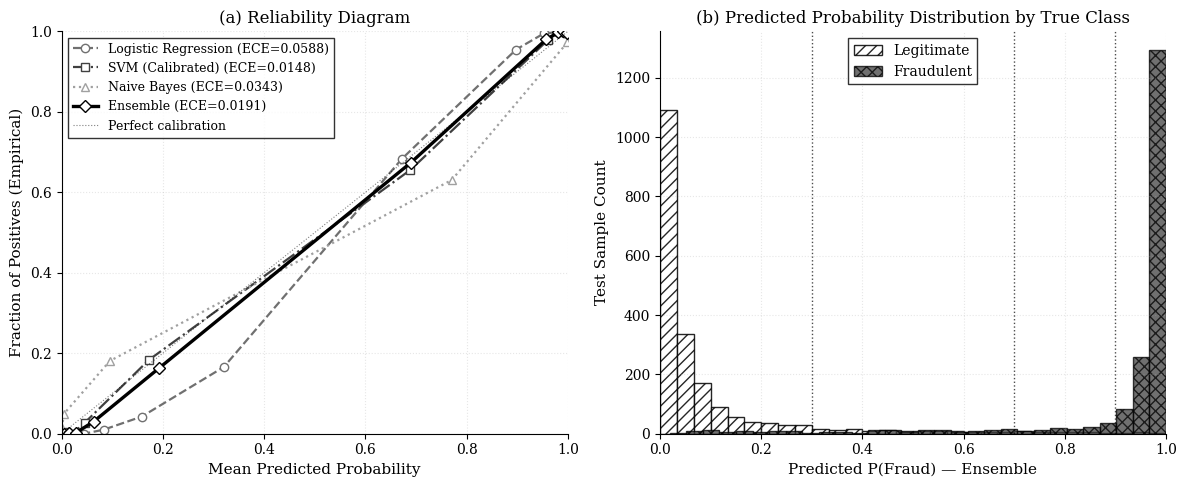


Ensemble Expected Calibration Error (ECE): 0.0191


In [20]:
# ============================================================
# FIGURE: Calibration curves + Probability histogram
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Reliability diagram ---
model_curves_cal = [
    ('Logistic Regression', p_lr_test,  GRAY[2], '--', 'o'),
    ('SVM (Calibrated)',    p_svm_test, GRAY[1], '-.', 's'),
    ('Naive Bayes',         p_nb_test,  GRAY[3], ':',  '^'),
    ('Ensemble',            p_ens_test, GRAY[0], '-',  'D'),
]

def expected_calibration_error(y_true, probs, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() > 0:
            acc  = y_true[mask].mean()
            conf = probs[mask].mean()
            ece += (mask.sum() / len(probs)) * abs(acc - conf)
    return ece

for name, probs, color, ls, marker in model_curves_cal:
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10, strategy='quantile')
    ece = expected_calibration_error(y_test.values, probs)
    lw = 2.4 if name == 'Ensemble' else 1.6
    axes[0].plot(mean_pred, frac_pos, color=color, linestyle=ls, linewidth=lw,
                 marker=marker, markersize=6, markerfacecolor='white',
                 markeredgecolor=color, label=f'{name} (ECE={ece:.4f})')

axes[0].plot([0, 1], [0, 1], 'k:', linewidth=0.8, alpha=0.5, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (Empirical)')
axes[0].set_title('(a) Reliability Diagram')
axes[0].legend(loc='upper left', frameon=True, fancybox=False, edgecolor='black', fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# --- Probability histogram (ensemble) ---
legit_probs = p_ens_test[y_test.values == 0]
fraud_probs = p_ens_test[y_test.values == 1]

axes[1].hist(legit_probs, bins=30, color='white',  edgecolor='black',
             linewidth=1.0, hatch='///', label='Legitimate', alpha=0.85)
axes[1].hist(fraud_probs, bins=30, color=GRAY[1], edgecolor='black',
             linewidth=1.0, hatch='xxx', label='Fraudulent', alpha=0.75)

for t in [0.30, 0.70, 0.90]:
    axes[1].axvline(t, color='black', linestyle=':', linewidth=1.0, alpha=0.7)

axes[1].set_xlabel('Predicted P(Fraud) — Ensemble')
axes[1].set_ylabel('Test Sample Count')
axes[1].set_title('(b) Predicted Probability Distribution by True Class')
axes[1].legend(loc='upper center', frameon=True, fancybox=False, edgecolor='black')
axes[1].set_xlim(0, 1)

plt.tight_layout()
save_fig(fig, 'fig_calibration')
plt.show()

ece_ensemble = expected_calibration_error(y_test.values, p_ens_test)
print(f'\nEnsemble Expected Calibration Error (ECE): {ece_ensemble:.4f}')

## 15. Ensemble Weight Ablation Table

In [21]:
# Show the top-10 weight combinations from the grid search,
# plus a few key reference configurations

weight_df = pd.DataFrame(weight_grid)
weight_df = weight_df.sort_values('Macro F1 (Val)', ascending=False).reset_index(drop=True)

# Pick a few illustrative rows for the report
key_configs = []
for label, target in [
    ('Equal weights',    (0.3, 0.3, 0.3)),  # closest to (0.33, 0.33, 0.33)
    ('LR-heavy',         (0.5, 0.3, 0.2)),
    ('SVM-heavy',        (0.2, 0.6, 0.2)),
    ('NB-heavy',         (0.2, 0.3, 0.5)),
]:
    matches = weight_df[(weight_df['w_LR']==target[0]) &
                        (weight_df['w_SVM']==target[1]) &
                        (weight_df['w_NB']==target[2])]
    if not matches.empty:
        row = matches.iloc[0].to_dict()
        row['Config'] = label
        key_configs.append(row)

best_row = weight_df.iloc[0].to_dict()
best_row['Config'] = 'Best (selected)'
key_configs.append(best_row)

ablation_df = pd.DataFrame(key_configs)[['Config', 'w_LR', 'w_SVM', 'w_NB', 'Macro F1 (Val)']]
ablation_df = ablation_df.drop_duplicates().reset_index(drop=True)

# Add corresponding TEST set Macro F1 for selected configs (fairness)
test_f1s = []
for _, r in ablation_df.iterrows():
    blended = r['w_LR'] * lr.predict_proba(X_test_vec) \
            + r['w_SVM'] * svm_cal.predict_proba(X_test_vec) \
            + r['w_NB'] * nb.predict_proba(X_test_vec)
    preds = (blended[:, 1] > 0.5).astype(int)
    test_f1s.append(f1_score(y_test, preds, average='macro'))
ablation_df['Macro F1 (Test)'] = test_f1s

print('Ensemble Weight Ablation')
print('=' * 70)
print(ablation_df.to_string(index=False, float_format='%.4f'))
ablation_df.to_csv(FIG_DIR / 'table_ensemble_ablation.csv', index=False)

Ensemble Weight Ablation
         Config   w_LR  w_SVM   w_NB  Macro F1 (Val)  Macro F1 (Test)
       LR-heavy 0.5000 0.3000 0.2000          0.9396           0.9472
      SVM-heavy 0.2000 0.6000 0.2000          0.9404           0.9469
       NB-heavy 0.2000 0.3000 0.5000          0.9391           0.9479
Best (selected) 0.2000 0.5000 0.3000          0.9426           0.9484


## 16. 5-Fold Cross-Validation (Variance Analysis)

In [22]:
cv_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2), min_df=3, max_df=0.85,
        stop_words=CUSTOM_STOPWORDS, max_features=20000, sublinear_tf=True)),
    ('clf', LogisticRegression(
        max_iter=1000, C=0.5,
        class_weight={0: 1.0, 1: 1.5}, solver='lbfgs'))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_pipeline, X, y, cv=skf, scoring='f1_macro', n_jobs=1)

print(f'5-fold CV Macro F1 : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold scores    : {[round(float(s), 4) for s in cv_scores]}')

5-fold CV Macro F1 : 0.9348 ± 0.0034
Per-fold scores    : [0.9378, 0.9306, 0.9363, 0.9308, 0.9383]


  saved -> figures/fig_cv_variance.png  &  figures/fig_cv_variance.pdf


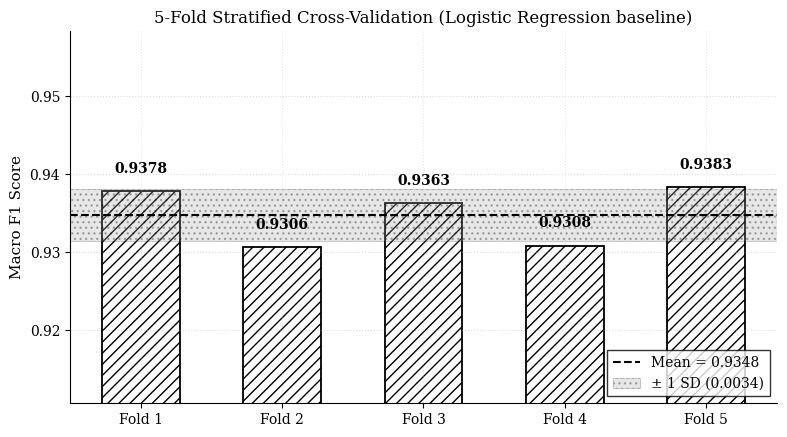

In [23]:
# ============================================================
# FIGURE: CV variance (bar chart with mean line)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.5))
folds = np.arange(1, len(cv_scores) + 1)

bars = ax.bar(folds, cv_scores, color='white', edgecolor='black',
              linewidth=1.3, hatch='///', width=0.55)
for bar, s in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, s + 0.002,
            f'{s:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(cv_scores.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.fill_between([0.5, len(cv_scores) + 0.5],
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                color=GRAY[3], alpha=0.25, hatch='...',
                edgecolor='black', linewidth=0.5,
                label=f'± 1 SD ({cv_scores.std():.4f})')

ax.set_xticks(folds)
ax.set_xticklabels([f'Fold {i}' for i in folds])
ax.set_ylabel('Macro F1 Score')
ax.set_title('5-Fold Stratified Cross-Validation (Logistic Regression baseline)')
ax.set_ylim(cv_scores.min() - 0.02, cv_scores.max() + 0.02)
ax.set_xlim(0.5, len(cv_scores) + 0.5)
ax.legend(loc='lower right', frameon=True, fancybox=False, edgecolor='black')
ax.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
save_fig(fig, 'fig_cv_variance')
plt.show()

## 17. Top Fraud-Indicative Tokens (LR Coefficient Analysis)

Provides explainability evidence for the report's "Word Risk Heatmap" claim.

In [24]:
# Pull LR coefficients from the word-level vectorizer only (more interpretable)
feature_names_word = word_vectorizer.get_feature_names_out()
n_word_feats = len(feature_names_word)
lr_coefs = lr.coef_.ravel()[:n_word_feats]

top_fraud = np.argsort(lr_coefs)[-20:][::-1]
top_legit = np.argsort(lr_coefs)[:20]

fraud_tokens = [(feature_names_word[i], lr_coefs[i]) for i in top_fraud]
legit_tokens = [(feature_names_word[i], lr_coefs[i]) for i in top_legit]

print('Top 20 Fraud-Indicative Tokens (high positive coefficient)')
print('-' * 50)
for tok, w in fraud_tokens:
    print(f'  {tok:<30s}  {w:+.4f}')

print('\nTop 20 Legit-Indicative Tokens (high negative coefficient)')
print('-' * 50)
for tok, w in legit_tokens:
    print(f'  {tok:<30s}  {w:+.4f}')

Top 20 Fraud-Indicative Tokens (high positive coefficient)
--------------------------------------------------
  suspicious_url                  +3.9301
  smish                           +2.5677
  click url                       +1.8625
  pay money_amount                +1.8458
  phone_number                    +1.8071
  money_amount_usd                +1.5033
  chat                            +1.4672
  document                        +1.4483
  monkey                          +1.4312
  click                           +1.4264
  txt                             +1.4133
  monkey org                      +1.4023
  whatsapp                        +1.3907
  jose                            +1.3858
  paris                           +1.2763
  claim                           +1.2698
  alert                           +1.2298
  porno                           +1.2274
  dvd                             +1.2267
  shocking                        +1.2187

Top 20 Legit-Indicative Tokens (high negative coe

  saved -> figures/fig_top_tokens.png  &  figures/fig_top_tokens.pdf


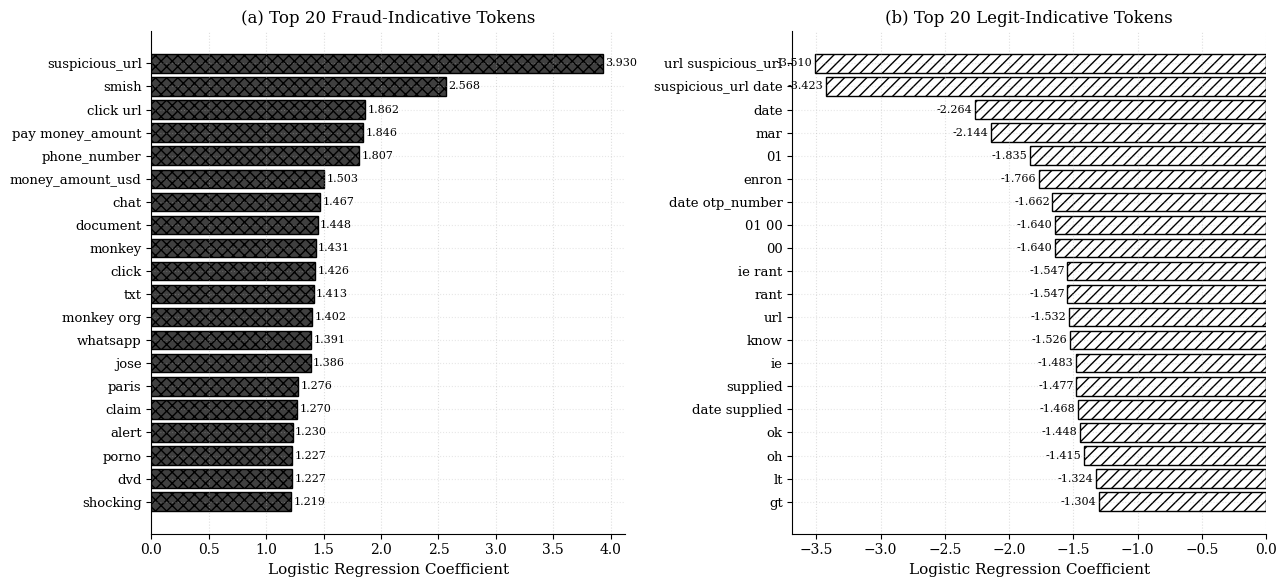

In [25]:
# ============================================================
# FIGURE: Top fraud/legit tokens (B&W horizontal bars)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Fraud-indicative
tokens_f = [t[0] for t in fraud_tokens][::-1]
weights_f = [t[1] for t in fraud_tokens][::-1]
y_pos = np.arange(len(tokens_f))
axes[0].barh(y_pos, weights_f, color=GRAY[1], edgecolor='black',
             linewidth=1.0, hatch='xxx')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(tokens_f, fontsize=9.5)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('(a) Top 20 Fraud-Indicative Tokens')
axes[0].grid(axis='x', linestyle=':', alpha=0.4)
for i, w in enumerate(weights_f):
    axes[0].text(w + 0.02, i, f'{w:.3f}', va='center', fontsize=8)

# Legit-indicative
tokens_l = [t[0] for t in legit_tokens][::-1]
weights_l = [t[1] for t in legit_tokens][::-1]
y_pos = np.arange(len(tokens_l))
axes[1].barh(y_pos, weights_l, color='white', edgecolor='black',
             linewidth=1.0, hatch='///')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(tokens_l, fontsize=9.5)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('(b) Top 20 Legit-Indicative Tokens')
axes[1].grid(axis='x', linestyle=':', alpha=0.4)
for i, w in enumerate(weights_l):
    axes[1].text(w - 0.02, i, f'{w:.3f}', va='center', ha='right', fontsize=8)

plt.tight_layout()
save_fig(fig, 'fig_top_tokens')
plt.show()

## 18. Summary Table for Report (One-Stop View)

In [26]:
summary = {
    'Dataset': {
        'Total samples':         n_total,
        'Fraud samples':         n_fraud,
        'Legit samples':         n_legit,
        'Fraud ratio':           f'{n_fraud/n_total:.4f}',
        'Train size':            len(X_train),
        'Validation size':       len(X_val),
        'Test size':             len(X_test),
    },
    'Vectorization': {
        'Total features':        X_train_vec.shape[1],
        'Word n-gram features':  len(word_vectorizer.vocabulary_),
        'Char n-gram features':  len(char_vectorizer.vocabulary_),
    },
    'Ensemble': {
        'LR weight':             W_LR,
        'SVM weight':            W_SVM,
        'NB weight':             W_NB,
        'Validation Macro F1':   f'{best_f1:.4f}',
    },
    'Hard Negative Mining': {
        'Hard examples mined':   len(hard_texts),
        'False positives mined': n_hard_fp,
        'False negatives mined': n_hard_fn,
        'Duplication factor':    DUPLICATION,
    },
    'Test Set Performance (Pre-HNM)':  {k: f'{v:.4f}' for k, v in pre_metrics.items()},
    'Test Set Performance (Post-HNM)': {k: f'{v:.4f}' for k, v in post_metrics.items()},
    'Cross-Validation': {
        'CV Macro F1 mean':      f'{cv_scores.mean():.4f}',
        'CV Macro F1 std':       f'{cv_scores.std():.4f}',
    },
    'Calibration': {
        'Ensemble ECE':          f'{ece_ensemble:.4f}',
    },
}

print('=' * 65)
print('  CYBERSHIELD — REPORT-READY SUMMARY')
print('=' * 65)
for section, items in summary.items():
    print(f'\n[{section}]')
    for k, v in items.items():
        print(f'  {k:<28s} : {v}')

# Persist as JSON for later reference
import json
with open(FIG_DIR / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f'\nSummary saved to: figures/summary.json')

  CYBERSHIELD — REPORT-READY SUMMARY

[Dataset]
  Total samples                : 26534
  Fraud samples                : 12852
  Legit samples                : 13682
  Fraud ratio                  : 0.4844
  Train size                   : 18573
  Validation size              : 3980
  Test size                    : 3980

[Vectorization]
  Total features               : 25000
  Word n-gram features         : 20000
  Char n-gram features         : 5000

[Ensemble]
  LR weight                    : 0.2
  SVM weight                   : 0.5
  NB weight                    : 0.3
  Validation Macro F1          : 0.9426

[Hard Negative Mining]
  Hard examples mined          : 228
  False positives mined        : 93
  False negatives mined        : 135
  Duplication factor           : 1

[Test Set Performance (Pre-HNM)]
  Accuracy                     : 0.9482
  Precision                    : 0.9508
  Recall                       : 0.9419
  Macro F1                     : 0.9482
  ROC-AUC            

## 19. Save Final Artifacts

In [27]:
with open('final_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('final_models.pkl', 'wb') as f:
    pickle.dump({
        'lr':      lr,
        'nb':      nb,
        'svm':     svm_cal,
        'weights': best_weights
    }, f)

print('Saved:')
print('  final_vectorizer.pkl')
print('  final_models.pkl')
print(f'  {SPLIT_FILE}  (frozen split — do NOT delete)')
print('\nAll figures saved under ./figures/ as PNG (300 DPI) + PDF (vector).')
print('Ready for direct LaTeX inclusion via \\includegraphics.')

Saved:
  final_vectorizer.pkl
  final_models.pkl
  split_indices.pkl  (frozen split — do NOT delete)

All figures saved under ./figures/ as PNG (300 DPI) + PDF (vector).
Ready for direct LaTeX inclusion via \includegraphics.


## 20. Quick Reference — Generated Figures & Tables

**Figures (in `./figures/`):**

| File | Use in Report |
|------|---------------|
| `fig_class_distribution.pdf` | Section 6.2 — Dataset overview |
| `fig_individual_models.pdf` | Section 6.3.4 — Single-model baselines |
| `fig_roc_pr_curves.pdf` | Section 6.3 — Model discrimination |
| `fig_pre_vs_post_hnm.pdf` | Section 6.3 — HNM ablation |
| `fig_confusion_matrices.pdf` | Section 6.4 — Error analysis |
| `fig_threshold_sensitivity.pdf` | Section 6.5 — Threshold strata |
| `fig_calibration.pdf` | Section 6.3.6 — Calibration validation |
| `fig_cv_variance.pdf` | Section 6.3.1 — CV stability |
| `fig_top_tokens.pdf` | Section 5.4 — Explainability evidence |

**Tables (CSV format, ready to convert to LaTeX):**

| File | Use in Report |
|------|---------------|
| `table_individual_models.csv` | Single-model comparison |
| `table_pre_vs_post_hnm.csv` | HNM ablation table |
| `table_threshold_sensitivity.csv` | Threshold sweep |
| `table_ensemble_ablation.csv` | Ensemble weight ablation |
| `summary.json` | All numbers in one place |

**To include a figure in your LaTeX report:**

```latex
\begin{figure}[h]
  \centering
  \includegraphics[width=0.85\textwidth]{figures/fig_pre_vs_post_hnm.pdf}
  \caption{Effect of Hard Negative Mining on test-set performance.}
  \label{fig:hnm-ablation}
\end{figure}
```